### Linear Regression (single feature) from Scratch without any built-in Libraries (except Numpy and Matplotlib)


In [117]:
def predict(x, w, b):
    prediction = w * x + b  # linear regression formula for single feature
    return prediction

In [118]:
def compute_cost(X, y, w, b):
    cost = 0
    m = len(X)

    for i in range(m):
        prediction = predict(X[i], w, b)
        error = prediction - y[i]   # predicted - actual
        cost += error ** 2
    
    cost = cost / (2 * m)   # here multiplying by 2 makes it easy to find the derivative for gradient descent

    return cost

In [119]:
def compute_gradient(X, y, w, b):
    dj_dw = 0
    dj_db = 0
    m = len(X)

    for i in range(m):
        prediction = predict(X[i], w, b)
        
        error = prediction - y[i]
        dj_dw += error * X[i]   # derivative of cost function w.r.t "w"
        dj_db += error  # # derivative of cost function w.r.t "w"

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db 

In [120]:
def gradient_descent(X, y, w, b, alpha=0.01, iterations=1000):

    cost_history = []

    for i in range(iterations):
        cost = compute_cost(X, y, w, b)
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw   # update weight
        b = b - alpha * dj_db   # update bias
        cost_history.append(cost)

    return w, b, cost_history


In [121]:
def train(X, y, alpha=0.01, iterations=1000):
    w = 10
    b = 5

    w, b, cost_history = gradient_descent(X, y, w, b)

    return w, b, cost_history

In [127]:
import pandas as pd

scores_data = pd.read_csv("scores_single_feature.csv")
scores_data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [123]:
X = scores_data['Hours']
y = scores_data['Scores']

w, b, cost_history = train(X, y)
print(f"Optimal values for w and b:")
print(f"w = {w:.2f}")
print(f"b = {b:.2f}")

print(f"\nFormula (Hypothesis):")
print(f"f(x) = {w:.2f}x + {b:.2f}")

prediction = predict(X[52], w, b)
print(f"Prediction of Score for Student who studied for {X[52]} hours:")
print(f"Predicted Score: {int(prediction.round())}")
print(f"Actual Score: {y[52]}")

Optimal values for w and b:
w = 9.82
b = 2.37

Formula (Hypothesis):
f(x) = 9.82x + 2.37
Prediction of Score for Student who studied for 6.6 hours:
Predicted Score: 67
Actual Score: 72


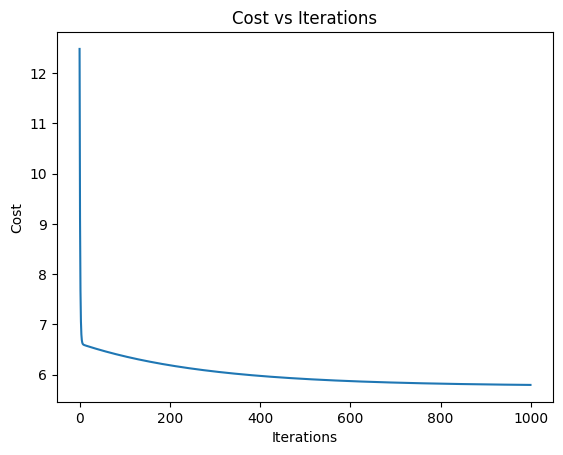

In [124]:
# plot the cost 

import matplotlib.pyplot as plt
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()

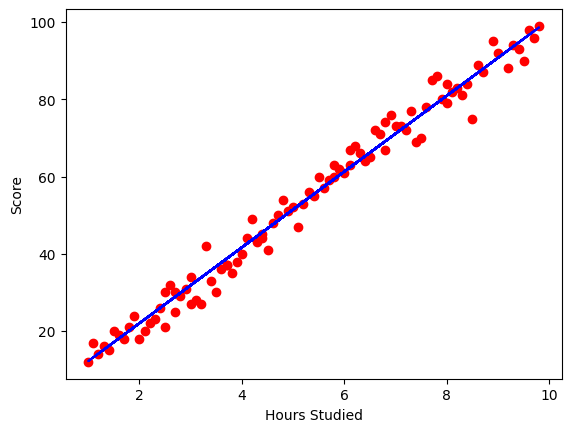

In [125]:
plt.scatter(X, y, c='r')
predictions = []

for x in X:
    predictions.append(predict(x, w, b))

plt.plot(X, predictions, c="b")
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.show()